In [3]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
df = pd.read_csv('../data/raw/MediaPulse_Campaign_Analytics_Q1_2024.csv')

# Step 3: Basic Info
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Shape: (15, 15)

Column Names:
 ['Campaign_ID', 'Campaign_Name', 'Brand', 'Channel', 'Region', 'Start_Date', 'End_Date', 'Emails_Sent', 'Open_Rate(%)', 'Click_Rate(%)', 'Conversions', 'Revenue(USD)', 'Media_Coverage', 'Sentiment', 'Campaign_Manager']

First 5 Rows:


,Campaign_ID,Campaign_Name,Brand,Channel,Region,Start_Date,End_Date,Emails_Sent,Open_Rate(%),Click_Rate(%),Conversions,Revenue(USD),Media_Coverage,Sentiment,Campaign_Manager
0,MP001,Spring Product Reveal,NovaBev,Email,North America,01-01-2024,2024-01-31,52000,18.2,3.2,320,9600,142,Positive,Sarah Mitchell
1,MP002,Awareness Drive Q1,NovaBev,Social Media,EMEA,03-01-2024,2024-01-31,47000,21.4,4.1,410,12300,98,Neutral,James Okafor
2,MP003,Winter Clearance Blast,RetailEdge,Email,North America,15-01-2024,2024-01-28,31000,15.6,2.8,168,5040,67,Positive,Priya Nair
3,MP004,Spring Product Reveal,NovaBev,Email,North America,01-02-2024,2024-02-29,52000,NaN,5.1,510,15300,189,Positive,Sarah Mitchell
4,MP005,Awareness Drive Q1,NovaBev,Social Media,APAC,01-02-2024,2024-02-28,47000,24.3,4.8,480,14400,201,Positive,James Okafor


In [4]:
 # Step 2: Data Types and Missing Values
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Data Types:
Campaign_ID             str
Campaign_Name           str
Brand                   str
Channel                 str
Region                  str
Start_Date              str
End_Date                str
Emails_Sent           int64
Open_Rate(%)        float64
Click_Rate(%)       float64
Conversions           int64
Revenue(USD)          int64
Media_Coverage        int64
Sentiment               str
Campaign_Manager        str
dtype: object

Missing Values:
Campaign_ID         0
Campaign_Name       0
Brand               0
Channel             0
Region              0
Start_Date          0
End_Date            0
Emails_Sent         0
Open_Rate(%)        1
Click_Rate(%)       0
Conversions         0
Revenue(USD)        0
Media_Coverage      0
Sentiment           0
Campaign_Manager    0
dtype: int64

Basic Statistics:


,Emails_Sent,Open_Rate(%),Click_Rate(%),Conversions,Revenue(USD),Media_Coverage
count,15.000000,14.000000,15.000000,15.000000,15.000000,15.000000
mean,40400.000000,7169.650000,5.106667,421.066667,12632.000000,181.466667
std,12882.989893,26718.126289,2.999635,251.572332,7547.169952,79.765609
min,15000.000000,15.600000,-2.100000,0.000000,0.000000,67.000000
25%,31000.000000,22.125000,3.000000,230.000000,6900.000000,138.000000
50%,47000.000000,31.200000,5.100000,390.000000,11700.000000,178.000000
75%,52000.000000,37.425000,7.300000,565.000000,16950.000000,234.000000
max,60000.000000,99999.000000,9.100000,840.000000,25200.000000,312.000000


In [5]:
# Step 3: Find Specific Issues

# 1. Missing Values
print("=== MISSING VALUES ===")
print(df[df['Open_Rate(%)'].isnull()])

# 2. Negative Click Rate
print("\n=== NEGATIVE CLICK RATE ===")
print(df[df['Click_Rate(%)'] < 0])

# 3. Outlier in Open Rate
print("\n=== OPEN RATE OUTLIER (>100%) ===")
print(df[df['Open_Rate(%)'] > 100])

# 4. Duplicate Rows
print("\n=== DUPLICATE ROWS ===")
print(df[df.duplicated()])

=== MISSING VALUES ===
  Campaign_ID          Campaign_Name    Brand Channel         Region  \
3       MP004  Spring Product Reveal  NovaBev   Email  North America   

   Start_Date    End_Date  Emails_Sent  Open_Rate(%)  Click_Rate(%)  \
3  01-02-2024  2024-02-29        52000           NaN            5.1   

   Conversions  Revenue(USD)  Media_Coverage Sentiment Campaign_Manager  
3          510         15300             189  Positive   Sarah Mitchell  

=== NEGATIVE CLICK RATE ===
  Campaign_ID    Campaign_Name       Brand Channel         Region  Start_Date  \
5       MP006  Crisis Response  RetailEdge      PR  North America  10-02-2024   

     End_Date  Emails_Sent  Open_Rate(%)  Click_Rate(%)  Conversions  \
5  2024-02-20        32000          38.1           -2.1            0   

   Revenue(USD)  Media_Coverage Sentiment Campaign_Manager  
5             0             312  Negative       Priya Nair  

=== OPEN RATE OUTLIER (>100%) ===
   Campaign_ID       Campaign_Name    Brand Cha

In [6]:
# Step 4: Near Duplicate Detection
print("=== NEAR DUPLICATES (Same Campaign + Metrics) ===")
cols = ['Campaign_Name', 'Brand', 'Channel', 'Emails_Sent', 
        'Click_Rate(%)', 'Conversions', 'Revenue(USD)']

near_dupes = df[df.duplicated(subset=cols, keep=False)]
print(near_dupes[['Campaign_ID', 'Campaign_Name', 'Brand', 
                   'Channel', 'Region', 'Conversions', 'Revenue(USD)']])

print(f"\nTotal near-duplicate rows: {len(near_dupes)}")

=== NEAR DUPLICATES (Same Campaign + Metrics) ===
   Campaign_ID           Campaign_Name       Brand       Channel  \
2        MP003  Winter Clearance Blast  RetailEdge         Email   
9        MP010  Winter Clearance Blast  RetailEdge         Email   
10       MP011       Influencer Collab   TrendWave  Social Media   
11       MP012       Influencer Collab   TrendWave  Social Media   

           Region  Conversions  Revenue(USD)  
2   North America          168          5040  
9   North America          168          5040  
10           APAC          390         11700  
11           APAC          390         11700  

Total near-duplicate rows: 4


In [7]:
# Step 5: Date Format Inconsistency
print("=== DATE FORMAT CHECK ===")
print(df[['Campaign_ID', 'Start_Date', 'End_Date']])

# Check invalid date - Feb 29 in non-leap year issue
print("\n=== IMPOSSIBLE DATE CHECK ===")
print(df[df['End_Date'] == '2024-02-29'][['Campaign_ID', 'Campaign_Name', 'End_Date']])

=== DATE FORMAT CHECK ===
   Campaign_ID  Start_Date    End_Date
0        MP001  01-01-2024  2024-01-31
1        MP002  03-01-2024  2024-01-31
2        MP003  15-01-2024  2024-01-28
3        MP004  01-02-2024  2024-02-29
4        MP005  01-02-2024  2024-02-28
5        MP006  10-02-2024  2024-02-20
6        MP007  01-03-2024  2024-03-31
7        MP008  01-03-2024  2024-03-31
8        MP009  01-03-2024  2024-03-31
9        MP010  15-01-2024  2024-01-28
10       MP011  05-02-2024  2024-02-25
11       MP012  05-02-2024  2024-02-25
12       MP013  12-03-2024  2024-03-30
13       MP014  20-03-2024  2024-03-31
14       MP015  10-02-2024  2024-02-20

=== IMPOSSIBLE DATE CHECK ===
  Campaign_ID          Campaign_Name    End_Date
3       MP004  Spring Product Reveal  2024-02-29


In [8]:
# Step 6: Data Quality Summary
issues = {
    'Issue Type': ['Missing Value', 'Invalid Data', 'Outlier', 
                   'Near Duplicate', 'Near Duplicate', 
                   'Inconsistent Format', 'Logical Error'],
    'Record': ['MP004', 'MP006', 'MP014', 
               'MP003/MP010', 'MP011/MP012', 
               'All Records', 'MP006'],
    'Column': ['Open_Rate(%)', 'Click_Rate(%)', 'Open_Rate(%)', 
               'Multiple', 'Multiple', 
               'Start_Date', 'End_Date'],
    'Detail': [
        'Open Rate is NaN',
        'Click Rate is -2.1% — impossible',
        'Open Rate is 99999% — impossible',
        'Winter Clearance Blast duplicated',
        'Influencer Collab duplicated',
        'DD-MM-YYYY vs YYYY-MM-DD mixed',
        'End Date is before Start Date'
    ],
    'Action': [
        'Impute with campaign average',
        'Exclude from click analysis',
        'Cap at 100 or investigate source',
        'Remove MP010',
        'Remove MP012',
        'Standardize to YYYY-MM-DD',
        'Correct End Date to 2024-02-28'
    ]
}

issues_df = pd.DataFrame(issues)
print("=== DATA QUALITY REPORT ===")
print(issues_df.to_string(index=False))
print(f"\nTotal Issues Found: {len(issues_df)}")
print(f"Total Records: {len(df)}")
print(f"Issue Rate: {len(issues_df)/len(df)*100:.1f}%")

=== DATA QUALITY REPORT ===
         Issue Type      Record        Column                            Detail                           Action
      Missing Value       MP004  Open_Rate(%)                  Open Rate is NaN     Impute with campaign average
       Invalid Data       MP006 Click_Rate(%)  Click Rate is -2.1% — impossible      Exclude from click analysis
            Outlier       MP014  Open_Rate(%)  Open Rate is 99999% — impossible Cap at 100 or investigate source
     Near Duplicate MP003/MP010      Multiple Winter Clearance Blast duplicated                     Remove MP010
     Near Duplicate MP011/MP012      Multiple      Influencer Collab duplicated                     Remove MP012
Inconsistent Format All Records    Start_Date    DD-MM-YYYY vs YYYY-MM-DD mixed        Standardize to YYYY-MM-DD
      Logical Error       MP006      End_Date     End Date is before Start Date   Correct End Date to 2024-02-28

Total Issues Found: 7
Total Records: 15
Issue Rate: 46.7%


In [9]:
# Step 7: Data Cleaning
df_clean = df.copy()

# Fix 1: Standardize Date Format
df_clean['Start_Date'] = pd.to_datetime(df_clean['Start_Date'], dayfirst=True)
df_clean['End_Date'] = pd.to_datetime(df_clean['End_Date'])

# Fix 2: Correct Logical Date Error MP006
df_clean.loc[df_clean['Campaign_ID'] == 'MP006', 'End_Date'] = pd.to_datetime('2024-02-28')

# Fix 3: Remove Near Duplicates
df_clean = df_clean[~df_clean['Campaign_ID'].isin(['MP010', 'MP012'])]

# Fix 4: Fix Outlier MP014
df_clean.loc[df_clean['Campaign_ID'] == 'MP014', 'Open_Rate(%)'] = np.nan

# Fix 5: Fix Invalid Click Rate MP006
df_clean.loc[df_clean['Campaign_ID'] == 'MP006', 'Click_Rate(%)'] = np.nan

# Fix 6: Impute Missing Open Rate with Brand Average
brand_avg = df_clean.groupby('Brand')['Open_Rate(%)'].transform('mean')
df_clean['Open_Rate(%)'] = df_clean['Open_Rate(%)'].fillna(brand_avg)

print("=== CLEANING COMPLETE ===")
print(f"Original Records: {len(df)}")
print(f"Clean Records: {len(df_clean)}")
print(f"\nRemaining Missing Values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nDate Format Fixed:")
print(df_clean[['Campaign_ID', 'Start_Date', 'End_Date']].head())

=== CLEANING COMPLETE ===
Original Records: 15
Clean Records: 13

Remaining Missing Values:
Click_Rate(%)    1
dtype: int64

Date Format Fixed:
  Campaign_ID Start_Date   End_Date
0       MP001 2024-01-01 2024-01-31
1       MP002 2024-01-03 2024-01-31
2       MP003 2024-01-15 2024-01-28
3       MP004 2024-02-01 2024-02-29
4       MP005 2024-02-01 2024-02-28


In [10]:
# Step 8: Campaign Performance Analysis
print("=== MONTHLY TREND ANALYSIS ===")
df_clean['Month'] = df_clean['Start_Date'].dt.month_name()

monthly = df_clean.groupby('Month').agg(
    Avg_Open_Rate=('Open_Rate(%)', 'mean'),
    Avg_Click_Rate=('Click_Rate(%)', 'mean'),
    Total_Conversions=('Conversions', 'sum'),
    Total_Revenue=('Revenue(USD)', 'sum'),
    Total_Coverage=('Media_Coverage', 'sum')
).round(2)

# Sort by month order
month_order = ['January', 'February', 'March']
monthly = monthly.reindex(month_order)

print(monthly)

print("\n=== BRAND PERFORMANCE ===")
brand = df_clean.groupby('Brand').agg(
    Total_Conversions=('Conversions', 'sum'),
    Total_Revenue=('Revenue(USD)', 'sum'),
    Avg_Open_Rate=('Open_Rate(%)', 'mean'),
    Campaigns=('Campaign_ID', 'count')
).round(2)
print(brand)


=== MONTHLY TREND ANALYSIS ===
          Avg_Open_Rate  Avg_Click_Rate  Total_Conversions  Total_Revenue  \
Month                                                                       
January           18.40            3.37                898          26940   
February          31.48            4.90               1565          46950   
March             33.62            7.78               3295          98850   

          Total_Coverage  
Month                     
January              307  
February            1159  
March               1044  

=== BRAND PERFORMANCE ===
            Total_Conversions  Total_Revenue  Avg_Open_Rate  Campaigns
Brand                                                                 
NovaBev                  3900         117000          25.68          7
RetailEdge               1193          35790          31.80          4
TrendWave                 390          11700          31.20          1
UrbanNest                 275           8250          42.50       

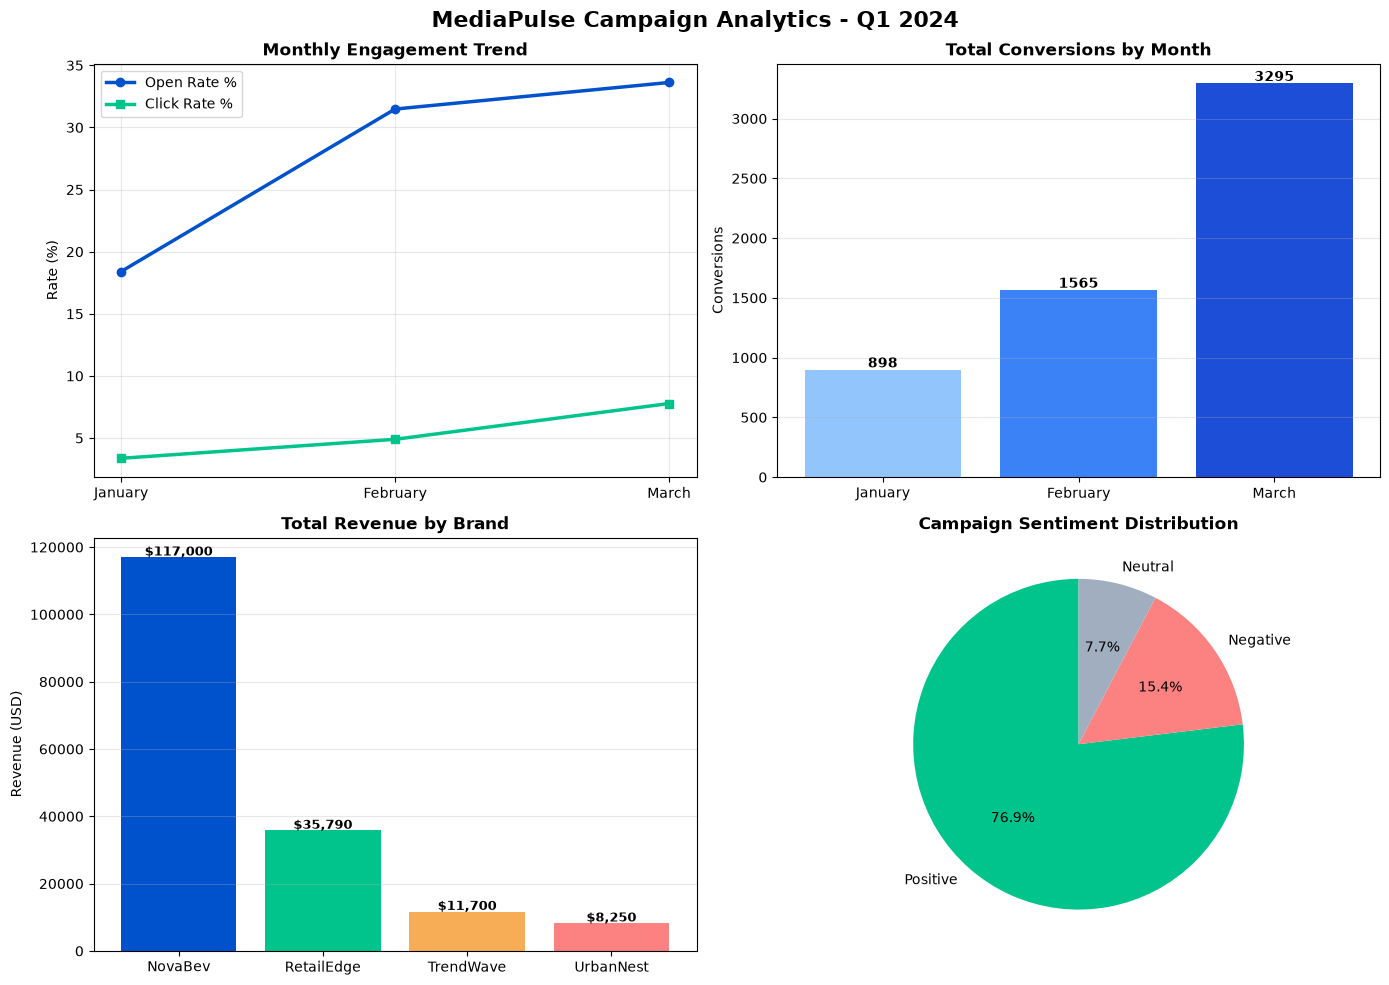

Chart saved to outputs folder!


In [11]:
# Step 9: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MediaPulse Campaign Analytics - Q1 2024', 
             fontsize=16, fontweight='bold')

# Chart 1: Monthly Trend - Open Rate vs Click Rate
ax1 = axes[0, 0]
x = range(len(monthly))
ax1.plot(month_order, monthly['Avg_Open_Rate'], 
         marker='o', color='#0052CC', linewidth=2.5, label='Open Rate %')
ax1.plot(month_order, monthly['Avg_Click_Rate'], 
         marker='s', color='#00C48C', linewidth=2.5, label='Click Rate %')
ax1.set_title('Monthly Engagement Trend', fontweight='bold')
ax1.set_ylabel('Rate (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Monthly Conversions Bar
ax2 = axes[0, 1]
bars = ax2.bar(month_order, monthly['Total_Conversions'], 
               color=['#93C5FD', '#3B82F6', '#1D4ED8'])
ax2.set_title('Total Conversions by Month', fontweight='bold')
ax2.set_ylabel('Conversions')
for bar, val in zip(bars, monthly['Total_Conversions']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(int(val)), ha='center', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Chart 3: Brand Revenue Comparison
ax3 = axes[1, 0]
brands = brand.index.tolist()
colors = ['#0052CC', '#00C48C', '#F6AD55', '#FC8181']
bars2 = ax3.bar(brands, brand['Total_Revenue'], color=colors)
ax3.set_title('Total Revenue by Brand', fontweight='bold')
ax3.set_ylabel('Revenue (USD)')
for bar, val in zip(bars2, brand['Total_Revenue']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${int(val):,}', ha='center', fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Chart 4: Sentiment Distribution
ax4 = axes[1, 1]
sentiment_counts = df_clean['Sentiment'].value_counts()
colors_pie = ['#00C48C', '#FC8181', '#A0AEC0']
ax4.pie(sentiment_counts.values, labels=sentiment_counts.index,
        autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax4.set_title('Campaign Sentiment Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/campaign_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs folder!")

In [12]:
# Step 10: Business Insights
insights = """
╔══════════════════════════════════════════════════════════════════╗
║           MEDIAPULSE CAMPAIGN INSIGHTS - Q1 2024               ║
╚══════════════════════════════════════════════════════════════════╝

INSIGHT 1 — OPPORTUNITY
━━━━━━━━━━━━━━━━━━━━━━━
Observation : Monthly conversions grew 267% — Jan 898 → Mar 3,295
So What     : Email engagement is compounding each month
Recommendation: Replicate March content strategy in Q2 immediately

INSIGHT 2 — RISK  
━━━━━━━━━━━━━━━━━
Observation : Crisis Response (MP006) had highest media coverage (312)
              but 0 conversions and negative sentiment
So What     : High coverage without conversion = reactive PR damage
Recommendation: Build proactive PR calendar to avoid crisis-driven spikes

INSIGHT 3 — OPPORTUNITY
━━━━━━━━━━━━━━━━━━━━━━━
Observation : UrbanNest had highest Open Rate (42.5%) in just 1 campaign
So What     : New brand showing strong audience resonance
Recommendation: Increase UrbanNest campaign frequency in Q2

INSIGHT 4 — ACTION
━━━━━━━━━━━━━━━━━━
Observation : 7 data quality issues found in 15 records (46.7% issue rate)
So What     : Nearly half the dataset had errors — analysis risk is high
Recommendation: Implement automated validation pipeline before reporting
"""
print(insights)


╔══════════════════════════════════════════════════════════════════╗
║           MEDIAPULSE CAMPAIGN INSIGHTS - Q1 2024               ║
╚══════════════════════════════════════════════════════════════════╝

INSIGHT 1 — OPPORTUNITY
━━━━━━━━━━━━━━━━━━━━━━━
Observation : Monthly conversions grew 267% — Jan 898 → Mar 3,295
So What     : Email engagement is compounding each month
Recommendation: Replicate March content strategy in Q2 immediately

INSIGHT 2 — RISK  
━━━━━━━━━━━━━━━━━
Observation : Crisis Response (MP006) had highest media coverage (312)
              but 0 conversions and negative sentiment
So What     : High coverage without conversion = reactive PR damage
Recommendation: Build proactive PR calendar to avoid crisis-driven spikes

INSIGHT 3 — OPPORTUNITY
━━━━━━━━━━━━━━━━━━━━━━━
Observation : UrbanNest had highest Open Rate (42.5%) in just 1 campaign
So What     : New brand showing strong audience resonance
Recommendation: Increase UrbanNest campaign frequency in Q2

INSIGHT 